# 12 - Comparing Regimes and Detecting Anomalies

This notebook demonstrates the `Comparison` mixin of `TimeSeries`. The focus is on
two closely related questions:

1. **How unusual is today's value compared to the past?**  (*anomaly detection*)
2. **Are two periods statistically different?**             (*regime comparison*)

These questions appear everywhere in climate science, hydrology, air-quality
monitoring, finance and beyond. As in the previous notebooks we assume no prior
statistics background and explain every concept before using it.

## 1. What is an anomaly?

An **anomaly** is simply the difference between an observation and a
reference value:

`anomaly_t = x_t - reference`

The reference is usually the long-term mean or median. Anomalies are often
more informative than raw values because:

- They remove the *baseline*. A 28 C day in Madrid and a 28 C day in
  Oslo are the same number, but Madrid's anomaly is near zero while
  Oslo's is large and positive.
- They are easy to sign - positive means above normal, negative below.
- They make comparisons across locations, seasons and variables possible.

## 2. Load data

We reuse the daily temperature series `temp.csv` from Notebook 10, and
later we will also load a second station to demonstrate the double-mass
curve.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statista.time_series import TimeSeries

DATA = '../../../examples/data/temp.csv'
df = pd.read_csv(DATA, parse_dates=['Date'], index_col='Date')
ts = TimeSeries(df)
print(ts.head())
print('Period:', ts.index.min().date(), '->', ts.index.max().date())

            Temp
Date            
1981-01-01  20.7
1981-01-02  17.9
1981-01-03  18.8
1981-01-04  14.6
1981-01-05  15.8
Period: 1981-01-01 -> 1990-12-31


## 3. `.anomaly(reference='mean')` - deviation from long-term mean

The first tool subtracts the overall mean from every observation:

`anomaly_t = x_t - mean(x)`

Positive values (shown in blue by the plotting method) are above-average
days; negative values (red) are below-average days.

In [2]:
anom_mean, _ = ts.anomaly(reference='mean', column='Temp', plot=False)
print('Mean of anomalies (should be ~0):', round(float(anom_mean.values.mean()), 6))
print('First five anomalies          :', np.round(anom_mean.values.flatten()[:5], 2))

Mean of anomalies (should be ~0): -0.0
First five anomalies          : [9.52 6.72 7.62 3.42 4.62]


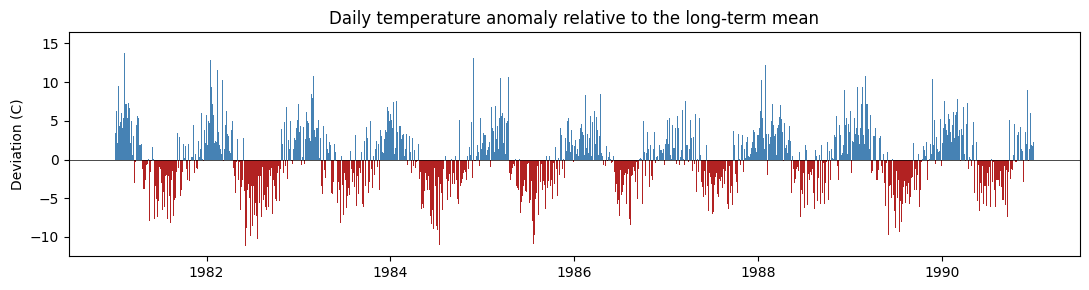

In [3]:
fig, ax = plt.subplots(figsize=(11, 3))
vals = anom_mean['Temp'].values
ax.bar(anom_mean.index, vals,
       color=['steelblue' if v >= 0 else 'firebrick' for v in vals], width=1.0, edgecolor='none')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Daily temperature anomaly relative to the long-term mean')
ax.set_ylabel('Deviation (C)')
plt.tight_layout()
plt.show()

Notice that because temperature has a strong annual cycle, the 'anomalies'
here are dominated by *summer* (blue) vs *winter* (red), not by truly
unusual weather. We will fix that in Section 5.

## 4. `.anomaly(reference='median')` - robust alternative

The mean is sensitive to a handful of extreme values. If the series contains
outliers (e.g. erroneously-recorded spikes), the mean shifts toward them and
the anomalies can be biased.

The **median** is the 50th percentile: half the data lie below, half above.
It is unaffected by outliers, so subtracting the median gives more robust
anomalies when the data are skewed or contaminated.

In [4]:
anom_med, _ = ts.anomaly(reference='median', column='Temp', plot=False)
print('First five anomalies (median ref):', np.round(anom_med.values.flatten()[:5], 2))
print('Overall mean shift   :', round(float(anom_mean.values.mean()), 4))
print('Overall median shift :', round(float(anom_med.values.mean()), 4))

First five anomalies (median ref): [9.7 6.9 7.8 3.6 4.8]
Overall mean shift   : -0.0
Overall median shift : 0.1778


## 5. `.standardized_anomaly()` - removing the seasonal cycle

For seasonal data the most useful anomaly is the **standardised** one.
For each calendar month we compute a climatological mean (mu_m) and
standard deviation (sigma_m), then:

`sa_t = (x_t - mu_m) / sigma_m`

with m the month of observation t. The result is dimensionless and
approximately **z-scored** per month:

- `sa = 0` : a typical day for that month.
- `|sa| > 1` : outside the 1-sigma band - mildly unusual.
- `|sa| > 2` : roughly in the outermost ~5% - quite unusual.
- `|sa| > 3` : very rare - typical threshold for a climate anomaly warning.

Crucially, `sa` values are **directly comparable between winter and summer**,
which plain deviations are not.

In [5]:
sa = ts.standardized_anomaly(column='Temp')
print('Mean of standardised anomalies (~0):', round(float(sa.values.mean()), 4))
print('Std  of standardised anomalies (~1):', round(float(sa.values.std()), 4))

Mean of standardised anomalies (~0): 0.0
Std  of standardised anomalies (~1): 0.9984


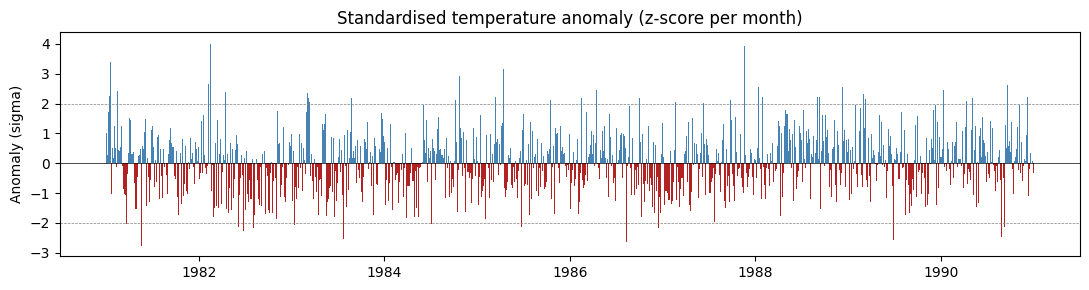

In [6]:
fig, ax = plt.subplots(figsize=(11, 3))
vals = sa['Temp'].values
ax.bar(sa.index, vals,
       color=['steelblue' if v >= 0 else 'firebrick' for v in vals], width=1.0, edgecolor='none')
for lvl in (-2, 2):
    ax.axhline(lvl, color='gray', linestyle='--', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Standardised temperature anomaly (z-score per month)')
ax.set_ylabel('Anomaly (sigma)')
plt.tight_layout()
plt.show()

This plot is far more informative: now a hot January shows up as a big blue
spike, and a cold July as a red spike, regardless of the absolute
temperature.

## 6. The double-mass curve - checking data consistency

Before any analysis we need to trust the data. A classical tool for
detecting *inhomogeneities* (gauge relocation, change of instrument, new
rating curve, land-use change ...) is the **double-mass curve**.

The idea: if two nearby stations measure the same underlying phenomenon,
their cumulative sums should plot as a straight line when drawn against
each other. Any *break in slope* betrays a moment when the relationship
between the two series changed, which normally indicates a problem at
one of them (not at both simultaneously).

Typical applications:

- Two rainfall gauges in the same catchment.
- Discharge at a gauge vs. a reference gauge upstream.
- Any pair of variables that should be proportional.

## 7. `.double_mass_curve()` - Rhine gauges example

We load two gauges from the Rhine dataset and check their consistency.

In [7]:
rhine = pd.read_csv('../../../examples/data/rhine-full-time-series.csv',
                    parse_dates=['date'], index_col='date')
pair = rhine[['cologne', 'rees']].dropna()
pair_ts = TimeSeries(pair)
print('Common valid days:', len(pair_ts))

Common valid days: 21186


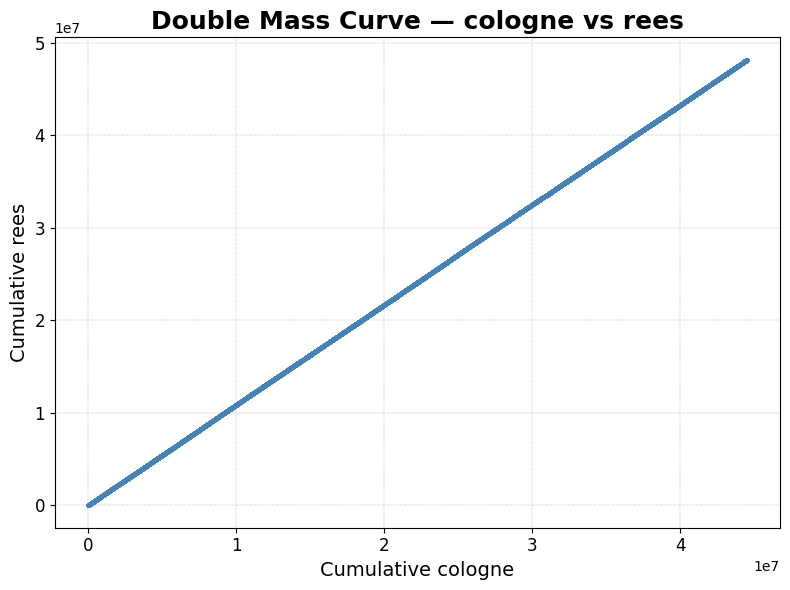

       cumsum_cologne   cumsum_rees
21181    4.450156e+07  4.815535e+07
21182    4.450237e+07  4.815608e+07
21183    4.450341e+07  4.815697e+07
21184    4.450459e+07  4.815806e+07
21185    4.450579e+07  4.815933e+07


In [8]:
dmc, _ = pair_ts.double_mass_curve('cologne', 'rees', plot=True)
print(dmc.tail())

A nearly straight line from origin to the top-right corner indicates that
the two gauges behave consistently over the whole record. Any visible elbow
would flag a period to investigate more carefully.

## 8. `.regime_comparison()` - before vs. after statistics

When we suspect a **regime shift** (for example after a dam construction,
a policy change or simply because a change-point detector found one), we
want to quantify how the distribution of the variable differs on the two
sides of the split.

`.regime_comparison(split_at=k)` computes:

- Descriptive statistics (mean, std, CV, median, min, max, skewness) before
  and after the split.
- **Relative change (%)** for each statistic.
- The **Mann-Whitney U test** p-value.

### Why Mann-Whitney?

The classical two-sample test is Student's t-test, but it assumes that the
data are normally distributed. Environmental series are usually skewed and
contain outliers, so we use the **Mann-Whitney U test**, a non-parametric
alternative. It tests whether one sample tends to have larger values than
the other, without any distributional assumption. A p-value below 0.05 is
the usual threshold for declaring a significant difference.

### Creating a synthetic regime shift

To demonstrate the method we deliberately inject a shift: from 1986 onwards
we add 2 C to every value, simulating a sudden warming event.

In [9]:
shifted = ts.copy()
shift_mask = shifted.index.year >= 1986
shifted.loc[shift_mask, 'Temp'] = shifted.loc[shift_mask, 'Temp'] + 2.0
shifted_ts = TimeSeries(shifted)

# Locate the split (first index where year == 1986)
split_at = int(np.argmax(shifted_ts.index.year >= 1986))
print('Split at row', split_at, '->', shifted_ts.index[split_at].date())

result = shifted_ts.regime_comparison(split_at=split_at, column='Temp')
print(result.round(4))

Split at row 1825 -> 1986-01-01
                   before     after relative_change_pct
mean            11.043507    13.312            20.54142
std               4.26272  3.868069           -9.258202
cv               0.385993   0.29057           -24.72148
median               10.9      13.2           21.100917
min                   0.0       2.5                 NaN
max                  26.3      26.1           -0.760456
skewness         0.210459  0.142952          -32.076101
mann_whitney_U  1151479.5       0.0                 NaN


Reading the output:

- `mean` shifts from the pre-1986 value to roughly 2 C higher - exactly
  the synthetic change we injected.
- `relative_change_pct` expresses each statistic's change as a percentage.
- `mann_whitney_U` row has the U statistic under `before` and the p-value
  under `after`. Because the p-value is essentially zero we reject the
  hypothesis that the two regimes come from the same distribution.

In [10]:
print('Mann-Whitney p-value:', float(result.loc['mann_whitney_U', 'after']))
print('Significant at 5%?  :', bool(float(result.loc['mann_whitney_U', 'after']) < 0.05))

Mann-Whitney p-value: 1.2937414816401833e-58
Significant at 5%?  : True


---

## Summary

| Method | Key idea | When to use |
|---|---|---|
| `anomaly(reference='mean')` | `x - mean(x)` | Quick deviations from baseline |
| `anomaly(reference='median')` | `x - median(x)` | Robust to outliers / skewness |
| `standardized_anomaly` | z-score per calendar month | Comparing across seasons |
| `double_mass_curve` | Cumulative X vs cumulative Y | Consistency check between two series |
| `regime_comparison(split_at=k)` | Stats + Mann-Whitney U | Quantifying a change before / after k |

Combined with the change-point detectors of the `Changepoint` mixin, these
methods form a complete workflow:

1. Detect a candidate change-point.
2. Compare regimes on both sides with `regime_comparison`.
3. Check that the change is not due to instrument drift via
   `double_mass_curve` against a reliable neighbouring station.
4. Re-express the series as standardised anomalies for follow-up analysis.